# Roxy viz module tutorial

This notebook demonstrates how to use the **Roxy viz module** on a
simulated classification dataset.

We will:

1. Generate a synthetic feature matrix and labels.
2. Compute a 2D PCA embedding using the Roxy projection module.
3. Visualise:
   - univariate feature distributions (with and without labels),
   - boxplots stratified by label,
   - scatter plots in feature space,
   - 2D embedding plots (PCA),
   - correlation heatmaps.
4. (Optionally) create interactive Plotly figures and a minimal
   `RoxyDashboard` if Plotly is installed.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification

from roxy.features import (
    infer_feature_kinds,
    ColumnScaler,
)
from roxy.projection import project
from roxy.viz import (
    plot_feature_distribution,
    plot_feature_boxplot,
    plot_scatter_features,
    plot_embedding,
    plot_correlation_heatmap,
    RoxyDashboard,
)

## 1. Generate a simulated classification dataset

We use `sklearn.datasets.make_classification` to generate a dataset with
20 numeric features and a binary label. This mimics a feature block
produced by Roxy (e.g. `seq_global` or combined descriptors).

In [2]:
X_num, y = make_classification(
    n_samples=400,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_repeated=0,
    n_clusters_per_class=2,
    class_sep=1.5,
    flip_y=0.03,
    random_state=42,
)

feature_names = [f"f{i}" for i in range(1, X_num.shape[1] + 1)]
df = pd.DataFrame(X_num, columns=feature_names)
target = pd.Series(y, name="label")

df.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,-0.856349,0.504582,-5.125331,1.700233,-3.012611,-0.745942,-3.591421,-0.614539,-0.611634,-3.757277,-0.346254,-1.049499,4.917199,-1.502871,-1.837191,3.492962,0.626538,-1.239562,0.753419,-0.661541
1,0.556553,0.257753,0.673417,0.353542,-1.902768,-1.907808,2.310563,1.887688,-1.335482,0.610092,-2.261808,-0.478163,0.939287,-0.155259,1.922556,2.566166,-1.241761,0.334176,-0.413606,-0.860385
2,-1.307370,-1.055089,-2.205620,-0.560278,1.359299,-0.423599,-0.841212,0.703428,-1.597872,0.787503,-2.507124,2.974150,1.098790,-0.792523,1.171275,-5.619259,0.126268,-0.984655,-0.974122,-1.365617
3,0.839664,-0.686279,0.975873,0.813138,-1.088523,0.514884,-1.875522,-0.532725,-1.357518,1.060243,0.728272,-0.131976,0.550930,0.585299,1.573537,-1.583697,-1.432671,0.145836,0.324340,0.819925
4,-0.073948,0.241322,3.484692,-0.000092,-0.922226,1.755476,2.691128,-0.150838,-0.451659,2.358294,-1.461856,-0.323512,-1.538259,-0.204471,3.865396,0.428105,-1.151014,0.386323,-0.465806,1.573020


## 2. Infer feature kinds, scale numerics, and compute a PCA embedding

We first standardise numeric features with `ColumnScaler`, then compute a
2D PCA embedding using the Roxy projection module. The PCA coordinates
will be used in subsequent plots as a generic 'embedding'.

In [3]:
# Infer feature types (here everything is numeric, but we keep the pattern)
kinds = infer_feature_kinds(df)
numeric_cols = [name for name, meta in kinds.items() if meta.kind.value == "numeric"]

numeric_cols

['f1',
 'f2',
 'f3',
 'f4',
 'f5',
 'f6',
 'f7',
 'f8',
 'f9',
 'f10',
 'f11',
 'f12',
 'f13',
 'f14',
 'f15',
 'f16',
 'f17',
 'f18',
 'f19',
 'f20']

In [4]:
# Scale numeric features
scaler = ColumnScaler(strategy="standard", columns=numeric_cols)
X_scaled = scaler.fit_transform(df)

X_scaled.head()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
0,-0.802089,0.504289,-2.209755,1.824559,-1.469853,-0.767974,-1.776680,-0.560970,-0.538945,-1.892169,0.976797,-0.277980,1.729877,-1.686361,-1.411090,0.786993,0.649616,-1.247816,0.747717,-0.599310
1,0.607111,0.261905,0.395788,0.251705,-0.936108,-1.940316,1.095197,1.925855,-1.229714,0.295551,-0.602354,0.025234,0.094114,-0.205704,0.586305,0.567012,-1.106888,0.384107,-0.408573,-0.795657
2,-1.251929,-1.027296,-0.897846,-0.815583,0.632683,-0.442724,-0.438441,0.748884,-1.480114,0.384421,-0.804589,1.857409,0.159703,-0.905884,0.187181,-1.375851,0.179281,-0.983484,-0.963934,-1.294546
3,0.889481,-0.665127,0.531689,0.788485,-0.544522,0.504220,-0.941732,-0.479661,-1.250743,0.521043,1.862617,0.208959,-0.065583,0.607967,0.400886,-0.417984,-1.286375,0.188803,0.322585,0.863558
4,-0.021738,0.245770,1.658973,-0.161319,-0.464546,1.755998,1.280379,-0.100123,-0.386282,1.171268,0.057113,0.107308,-0.924682,-0.259775,1.618455,0.059530,-1.021572,0.438181,-0.460293,1.607198


In [5]:
# Compute a 2D PCA embedding for visualisation
X_pca = project(X_scaled, method="pca", n_components=2, random_state=42)
X_pca[:5]

array([[ 4.39831927, -1.78872841],
       [ 0.18252113,  1.43127941],
       [-1.35433623, -2.01463041],
       [ 0.12261058, -0.91966915],
       [-1.94495116,  1.58219429]])

## 3. Univariate feature distributions

We can visualise the distribution of a single feature:

- without labels (overall distribution),
- with labels (class-conditional histograms).

<Figure size 500x400 with 0 Axes>

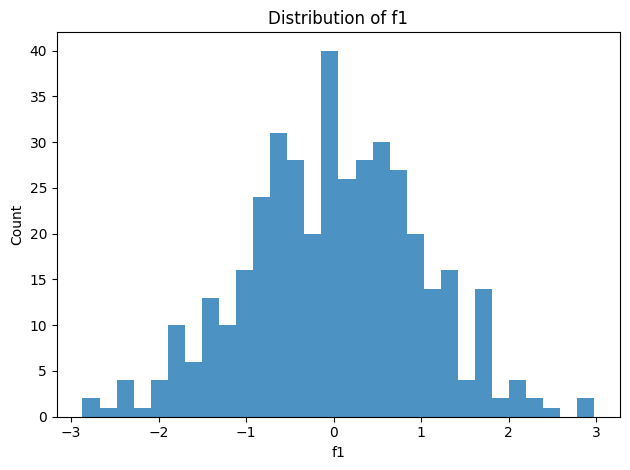

<Figure size 500x400 with 0 Axes>

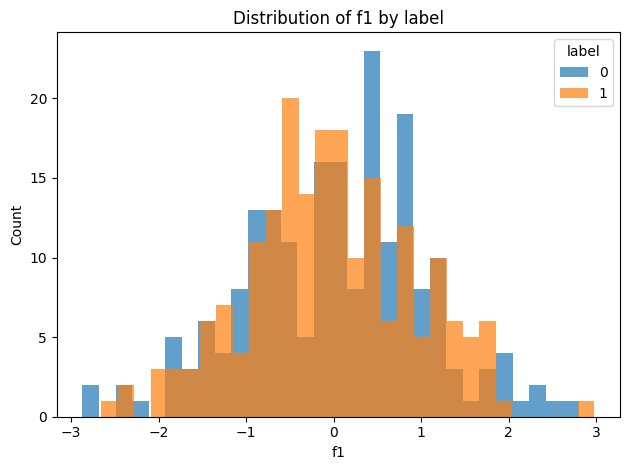

In [6]:
feature_to_plot = "f1"

# Overall distribution (no labels)
plt.figure(figsize=(5, 4))
plot_feature_distribution(X_scaled, feature_to_plot)
plt.tight_layout()
plt.show()

# Distribution stratified by label
plt.figure(figsize=(5, 4))
plot_feature_distribution(X_scaled, feature_to_plot, y=target)
plt.tight_layout()
plt.show()

## 4. Boxplots stratified by label

Boxplots allow us to quickly compare the distribution of a feature
across classes.

<Figure size 500x400 with 0 Axes>

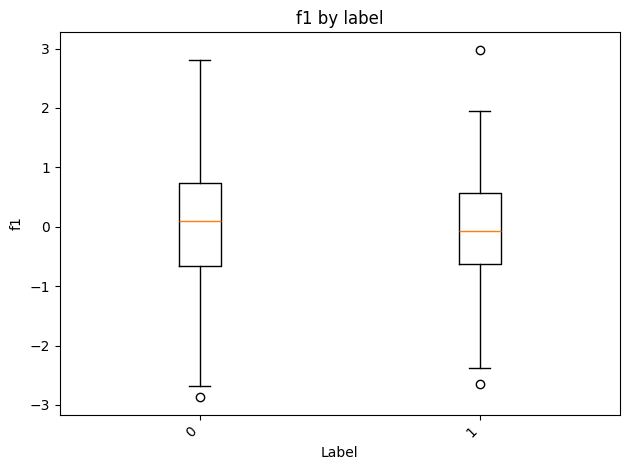

In [7]:
plt.figure(figsize=(5, 4))
plot_feature_boxplot(X_scaled, feature_to_plot, y=target)
plt.tight_layout()
plt.show()

## 5. Scatter plots in feature space

We can inspect pairwise relationships between features using scatter
plots, optionally colour-coded by label.

<Figure size 500x400 with 0 Axes>

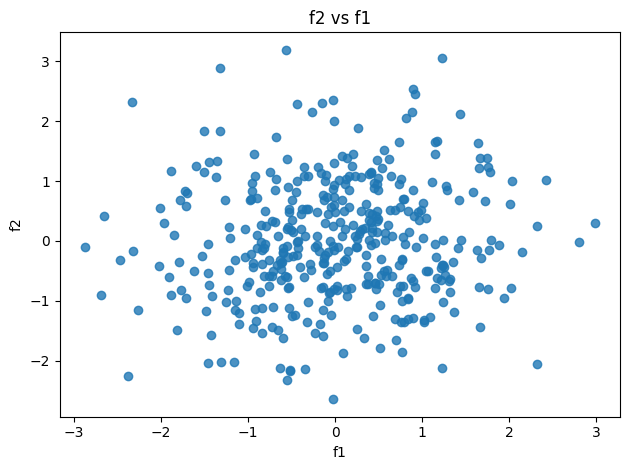

<Figure size 500x400 with 0 Axes>

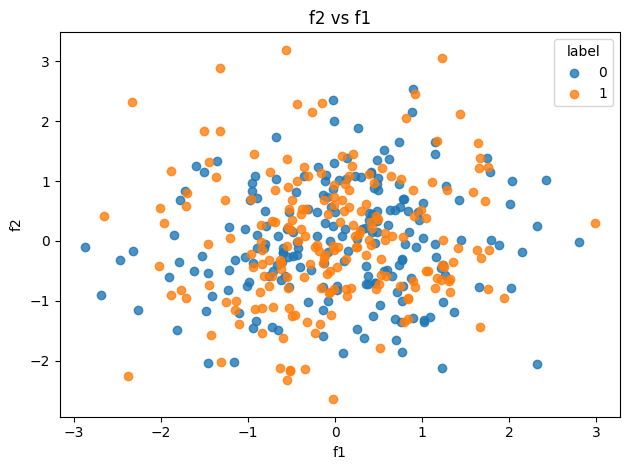

In [8]:
x_feat, y_feat = "f1", "f2"

plt.figure(figsize=(5, 4))
plot_scatter_features(X_scaled, x_feat, y_feat)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plot_scatter_features(X_scaled, x_feat, y_feat, y=target)
plt.tight_layout()
plt.show()

## 6. Embedding plots (e.g. PCA)

We can visualise low-dimensional embeddings (PCA, UMAP, t-SNE) using
`plot_embedding`. Here we use the PCA embedding computed above and
colour points by their label.

<Figure size 500x400 with 0 Axes>

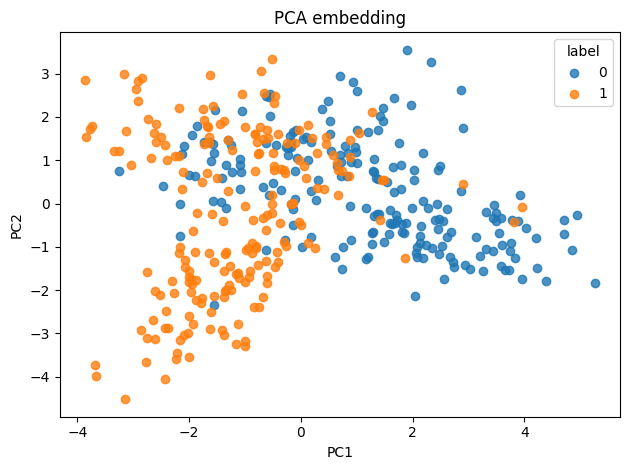

In [9]:
plt.figure(figsize=(5, 4))
plot_embedding(X_pca, y=target, labels=["PC1", "PC2"], title="PCA embedding")
plt.tight_layout()
plt.show()

## 7. Correlation heatmap

Finally, we can inspect correlations between numeric features using
`plot_correlation_heatmap`.

<Figure size 700x600 with 0 Axes>

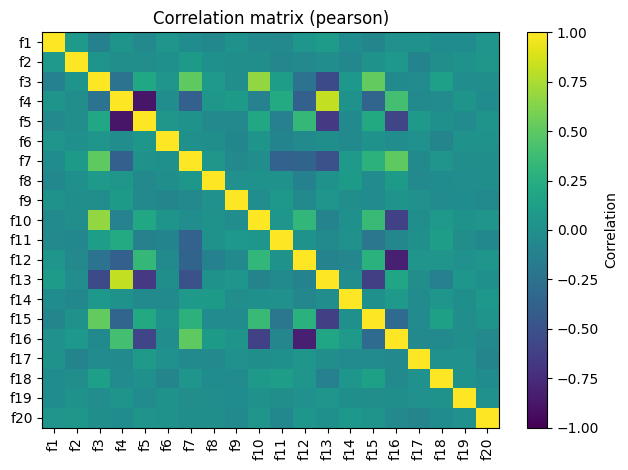

In [10]:
plt.figure(figsize=(7, 6))
plot_correlation_heatmap(X_scaled, method="pearson")
plt.tight_layout()
plt.show()

## 8. Interactive visualisation with Plotly and `RoxyDashboard` (optional)

If Plotly is installed, we can also create interactive figures for the
same concepts using the dashboard helpers.

If Plotly is not available, this section will simply print a message.


In [11]:
try:
    import plotly.io as pio

    # Build a dashboard instance
    dash = RoxyDashboard(X=X_scaled, y=target)
    dash.add_embedding("pca", X_pca)

    # 8.1 Interactive histogram
    fig_hist = dash.figure_distribution(feature_to_plot, nbins=30)
    fig_hist.show()

    # 8.2 Interactive PCA embedding with hover on a few features
    fig_emb = dash.figure_embedding(
        "pca",
        method_label="PCA",
        hover_columns=["f1", "f2", "f3"],
    )
    fig_emb.show()

except ImportError as e:
    print("Plotly is not available:", e)
    print("Install 'plotly' to enable interactive visualisations.")

## 9. Summary

In this notebook we have:

- Generated a synthetic feature matrix and labels.
- Scaled numeric features and computed a PCA embedding.
- Used `roxy.viz.plots` to create:
  - univariate histograms (with and without label stratification),
  - boxplots per label,
  - scatter plots in feature space,
  - embedding plots for PCA,
  - correlation heatmaps.
- Optionally, used `RoxyDashboard` and Plotly to generate interactive
  histograms and embedding plots.

These patterns can be reused directly on top of `RoxyDataset` feature
blocks and embeddings produced by the projection module.
